# CREDIT  RISK MODELLING 

# 1. Setting the Background
The most pressing questions for banks are how efficiently can we guage the risk profile of our customers and how can we use this information to decide on the required liquidity while still maintaining our regulatory obligations. 

With the constantly changing customer portfolio and the ever increasing customer base a more robust non-hardcoded approach is neccessary to achieve these antagonistic goals. 

Thus comes the idea of using machine learning to develop a behavioural scorecard to pull data from both internal sources, customer transactions and their demographic data, to predict the probability of default. 

In this notebook we are going to explore the data cleaning and transformation as well as machine learing modelling in predicting probability of default. We can then use these results to develop a credit rating. 

We will eplore the following concepts in the notebook
1. Data cleaning - Struucturing the data for modelling 
2. What to do with missing values 
3. How to deal with class imbalance and the implications. 


# 2. Libraries and Data Import

In [1]:
# General Libraries 

import warnings
warnings.filterwarnings('ignore')

# Data Explotation libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt #Visualization
import seaborn as sns #Advanced Visualization
%matplotlib inline

# Data modelling libraries
from sklearn.impute import SimpleImputer
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier 

from sklearn.metrics import classification_report, confusion_matrix
import itertools
from sklearn.metrics import f1_score

In [2]:
#Loading data 
Loan = pd.read_csv("raw-data.csv")
Loan.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32
0,1,0,0,24.0,0.0,2432.0,46500.0,24.0,1385.0,SC,...,NaN,NaN,46500.0,NaN,NaN,0,0,0,TIER 1,0
1,2,0,1,24.0,1.0,1495.0,28168.0,24.0,2496.0,MO,...,NaN,NaN,28168.0,NaN,NaN,0,0,0,TIER 1,0
2,3,0,0,26.0,0.0,1707.0,38900.0,30.0,1346.0,SC,...,NaN,105000.0,38900.0,34.0,31.0,31,31,16,TIER 1,0
3,4,0,0,24.0,0.0,2128.0,42900.0,24.0,1375.0,SC,...,NaN,NaN,42900.0,NaN,NaN,0,0,0,TIER 1,0
4,5,0,0,27.0,0.0,1824.0,40900.0,30.0,4140.0,MC,...,NaN,NaN,40900.0,NaN,NaN,0,0,0,TIER 1,0


In [3]:
#Renaming columns in the dataset with their correct names
Loan_renamed = Loan.rename(columns={'V1': 'Customer ID',
'V2': 'Customer has bounced in first EMI', 
'V3': 'No of times bounced 12 months',
'V4': 'Maximum MOB',
'V5': 'No of times bounced while repaying the loan',
'V6': 'EMI',
'V7': 'Loan Amount',
'V8': 'Tenure',
'V9': 'Dealer codes from where customer has purchased the Two wheeler',
'V10': 'Product code of Two wheeler', 
'V11': 'No of advance EMI paid',
'V12': 'Rate of interest',
'V13': 'Gender',
'V14': 'Employment type',
'V15': 'Resident type of customer',
'V16': 'Date of birth',
'V17': 'Customer age when loanwas taken',
'V18': 'No of loans',
'V19': 'No of secured loans',
'V20': 'No of unsecured loans',
'V21': 'Max amount sanctioned in the Live loans',
'V22': 'No of new loans in last 3 months',
'V23': 'Total sanctioned amount in the secured Loans which are Live',
'V24': 'Total sanctioned amount in the unsecured Loans which are Live',
'V25': 'Maximum amount sanctioned for any Two wheeler loan',
'V26': 'Time since last Personal loan taken (in months)',
'V27': 'Time since first consumer durables loan taken (in months)',
'V28': 'No of times 30 days past due in last 6 months',
'V29': 'No of times 60 days past due in last 6 months',
'V30': 'No of times 90 days past due in last 3 months',
'V31': 'Tier',
'V32': 'Target variable'})
Loan_renamed.head(2)

,Customer ID,Customer has bounced in first EMI,No of times bounced 12 months,Maximum MOB,No of times bounced while repaying the loan,EMI,Loan Amount,Tenure,Dealer codes from where customer has purchased the Two wheeler,Product code of Two wheeler,...,Total sanctioned amount in the secured Loans which are Live,Total sanctioned amount in the unsecured Loans which are Live,Maximum amount sanctioned for any Two wheeler loan,Time since last Personal loan taken (in months),Time since first consumer durables loan taken (in months),No of times 30 days past due in last 6 months,No of times 60 days past due in last 6 months,No of times 90 days past due in last 3 months,Tier,Target variable
0,1,0,0,24.0,0.0,2432.0,46500.0,24.0,1385.0,SC,...,NaN,NaN,46500.0,NaN,NaN,0,0,0,TIER 1,0
1,2,0,1,24.0,1.0,1495.0,28168.0,24.0,2496.0,MO,...,NaN,NaN,28168.0,NaN,NaN,0,0,0,TIER 1,0


# 3. Basic EDA and Data Cleaning

In [4]:
Loan_renamed.info()

<class 'pandas.DataFrame'>
RangeIndex: 119528 entries, 0 to 119527
Data columns (total 32 columns):
 #   Column                                                          Non-Null Count   Dtype  
---  ------                                                          --------------   -----  
 0   Customer ID                                                     119528 non-null  int64  
 1   Customer has bounced in first EMI                               119528 non-null  int64  
 2   No of times bounced 12 months                                   119528 non-null  int64  
 3   Maximum MOB                                                     85048 non-null   float64
 4   No of times bounced while repaying the loan                     85048 non-null   float64
 5   EMI                                                             85048 non-null   float64
 6   Loan Amount                                                     85048 non-null   float64
 7   Tenure                                           

In [5]:
missing_perc = Loan_renamed.isnull().sum() / len(Loan_renamed) * 100
print(missing_perc)

Customer ID                                                        0.000000
Customer has bounced in first EMI                                  0.000000
No of times bounced 12 months                                      0.000000
Maximum MOB                                                       28.846797
No of times bounced while repaying the loan                       28.846797
EMI                                                               28.846797
Loan Amount                                                       28.846797
Tenure                                                            28.846797
Dealer codes from where customer has purchased the Two wheeler    28.846797
Product code of Two wheeler                                       28.846797
No of advance EMI paid                                            28.846797
Rate of interest                                                  28.846797
Gender                                                            28.846797
Employment t

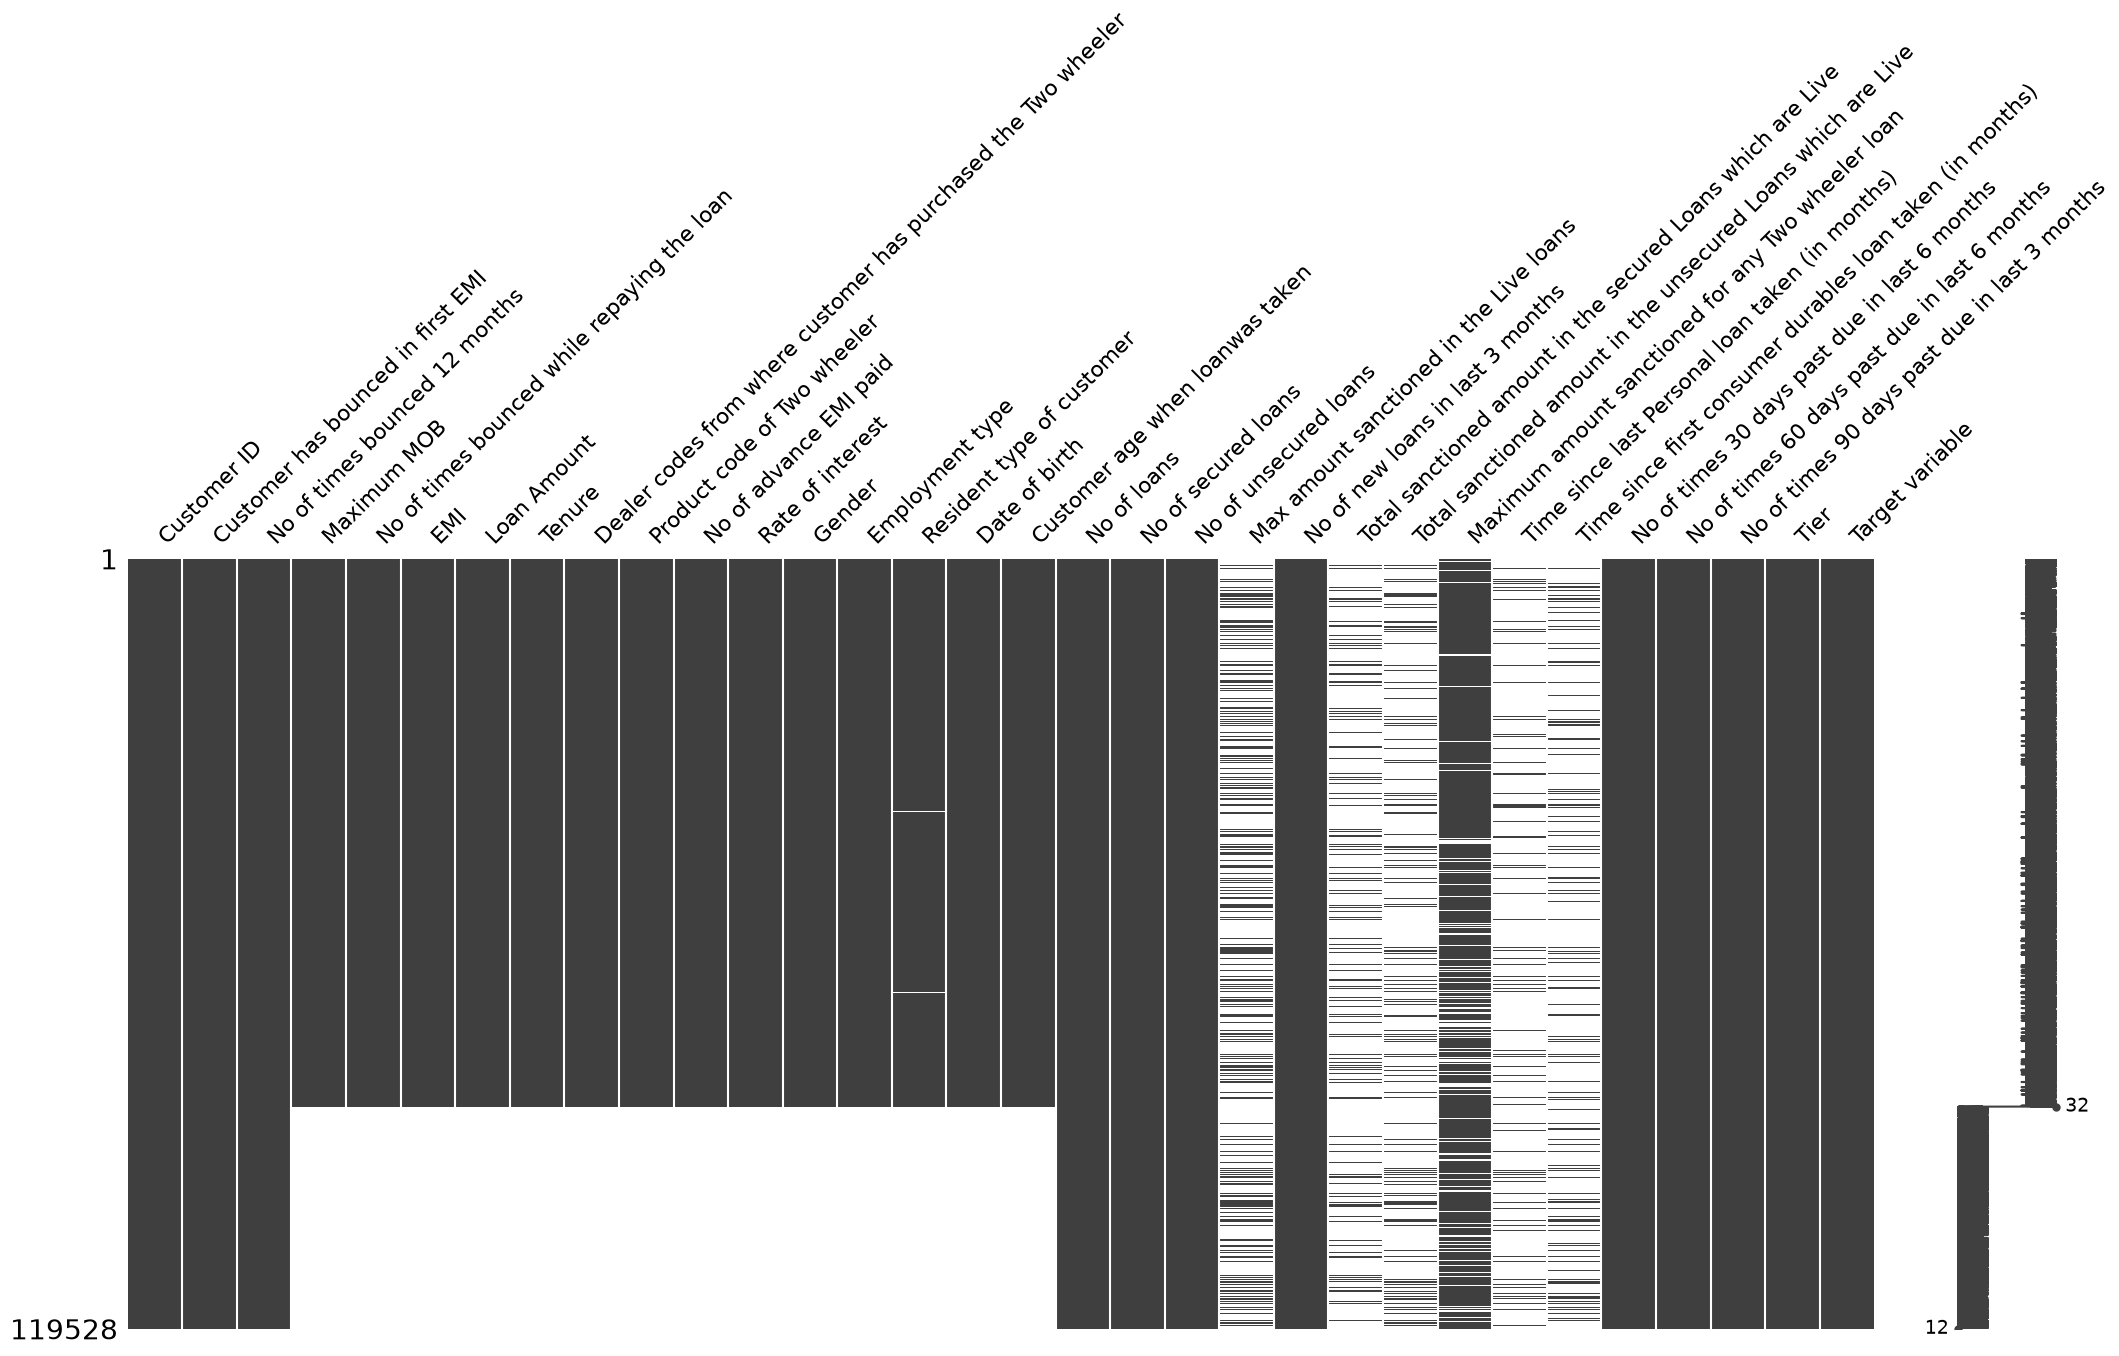

In [6]:
import missingno as msno
msno.matrix(Loan_renamed)
plt.show()

As illustrated there are quite a number of features with missing values, we will speak to this in the subsequent sections

In [7]:
#Removing irrelevant columns
# #irrelevant_columns = ['Time since first consumer durables loan taken (in months)','Time since last Personal loan taken (in months)']
# Loan_renamed.drop(['Time since first consumer durables loan taken (in months)','Time since last Personal loan taken (in months)'], axis = 1, inplace = True)
# Loan_renamed.shape
# Drop columns - too many missing values
Loan_renamed.drop(['Time since first consumer durables loan taken (in months)',
                   'Time since last Personal loan taken (in months)',
                   'Total sanctioned amount in the secured Loans which are Live',
                   'Total sanctioned amount in the unsecured Loans which are Live',
                   'Max amount sanctioned in the Live loans'
                   ], axis = 1, inplace = True)

Loan_renamed.shape

(119528, 27)

In [8]:
# Missing values treatment 
Loan_renamed.dropna(axis=0,how='any',subset=['Loan Amount','Gender'],inplace=True)

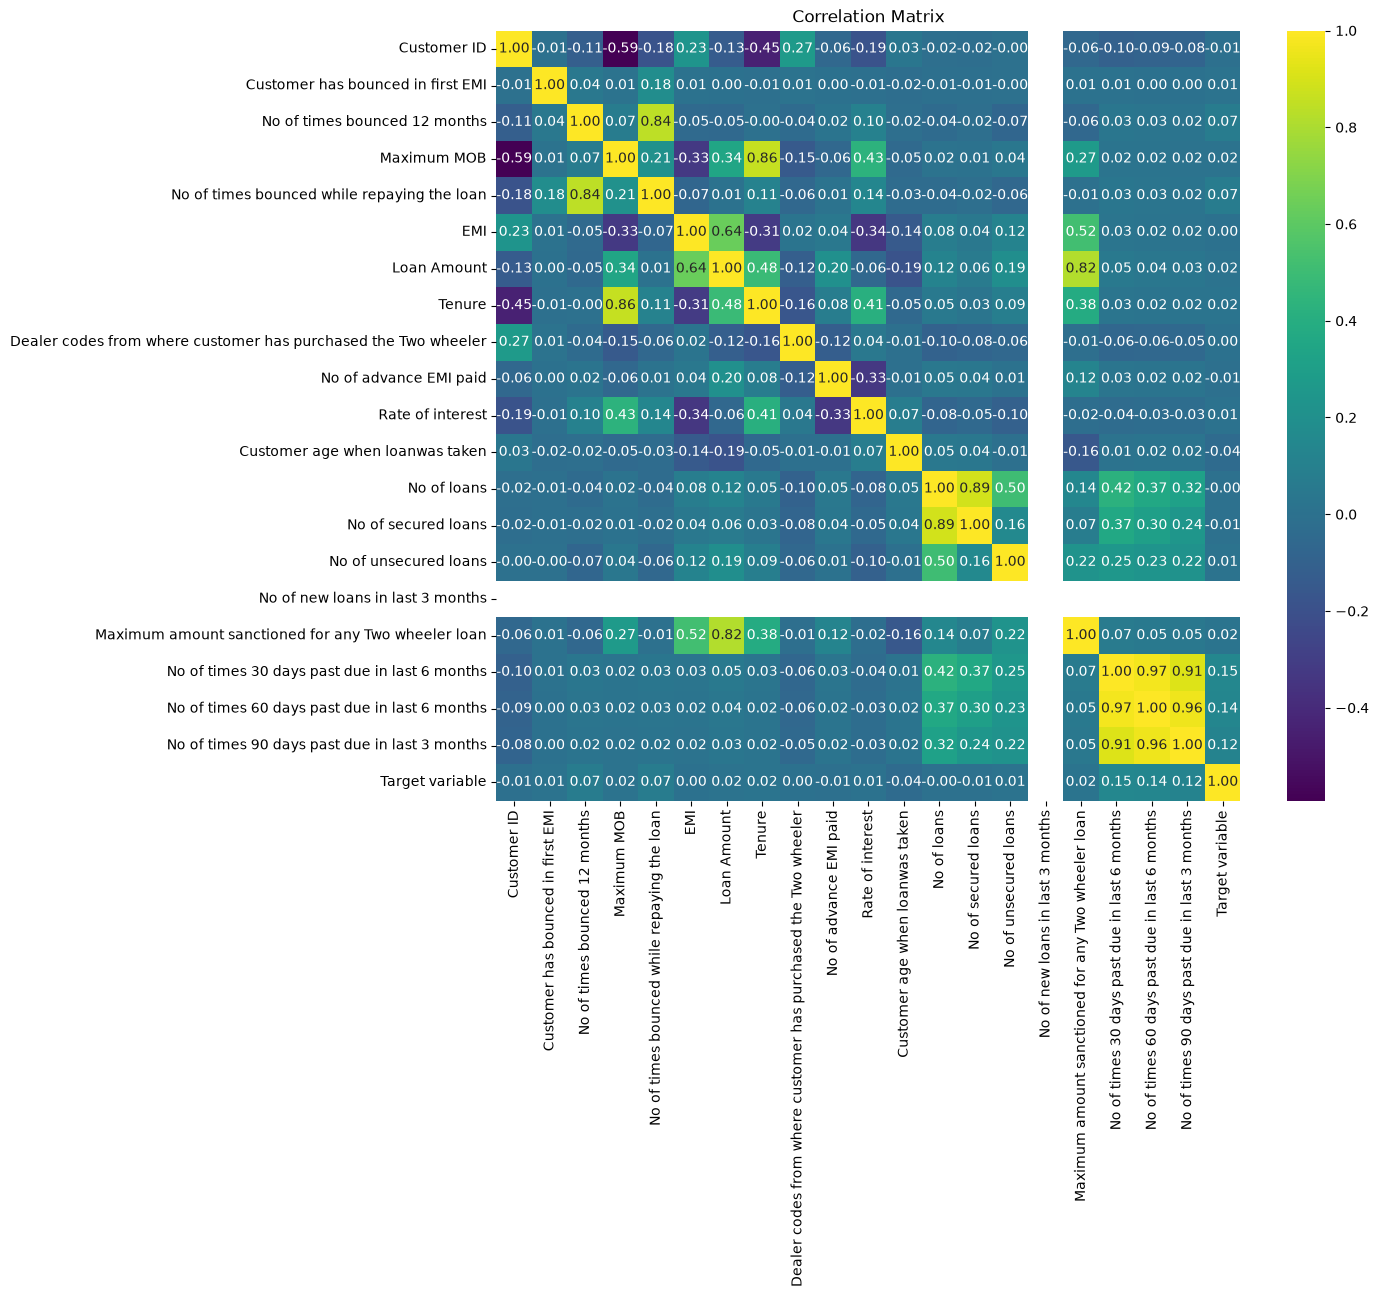

In [9]:
corrmat = Loan_renamed.select_dtypes(include='number').corr()

plt.figure(figsize=(12,10))
sns.heatmap(
    corrmat,
    annot=True,
    fmt=".2f",
    cmap="viridis"
)

plt.title("Correlation Matrix")
plt.show()

In [10]:
#correlation matrix
# corrmat = Loan_renamed.corr()
# top_corr_features = corrmat.index
# plt.figure(figsize=(20,20))
# g=sns.heatmap(Loan_renamed[top_corr_features].corr(),annot=True,cmap="viridis")

Target variable
0    83194
1     1854
Name: count, dtype: int64


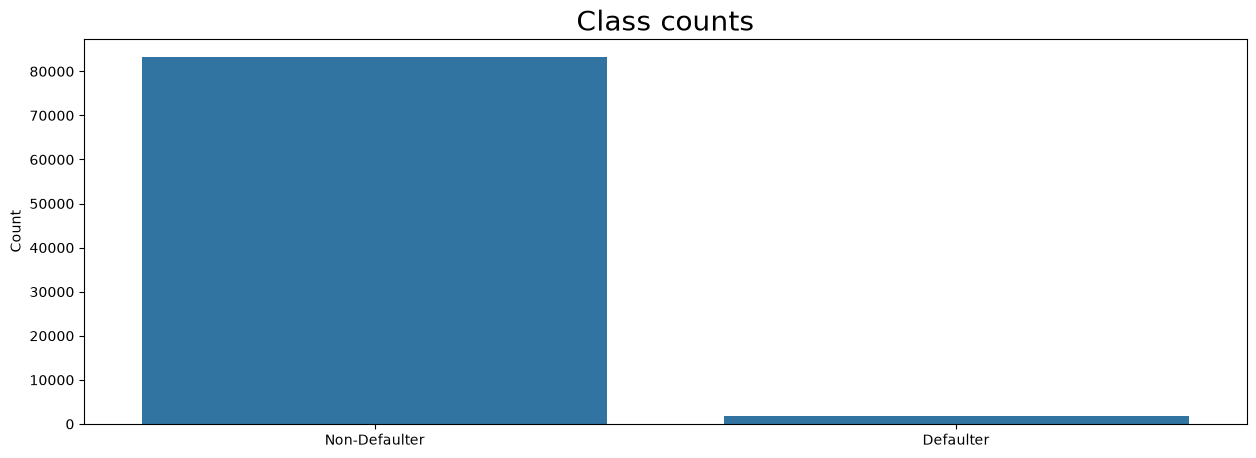

In [11]:
# Getting the number of positive and negative examples. 
plt.figure(figsize=(15,5))
sns.countplot(Loan_renamed, x='Target variable')
plt.xticks((0, 1), ["Non-Defaulter", "Defaulter"])
plt.xlabel("")
plt.ylabel("Count")
plt.title("Class counts", y=1, fontdict={"fontsize": 20})

print(Loan_renamed['Target variable'].value_counts())

The data set is pretty imbalanced as expected where positive examples defualters are significanltly less than 25%. We'll explain in the next section how to handle all of them after giving an overview of ensemble methods


<font color='white'>For the three plots about LOAN AMOUNT, you could indicate why each is significant and what insights it gives that are different from the other or maybe what it adds on.</font>

<Axes: title={'center': 'Loan Amount (Box Plot)'}, xlabel='Employment type', ylabel='Loan Amount'>

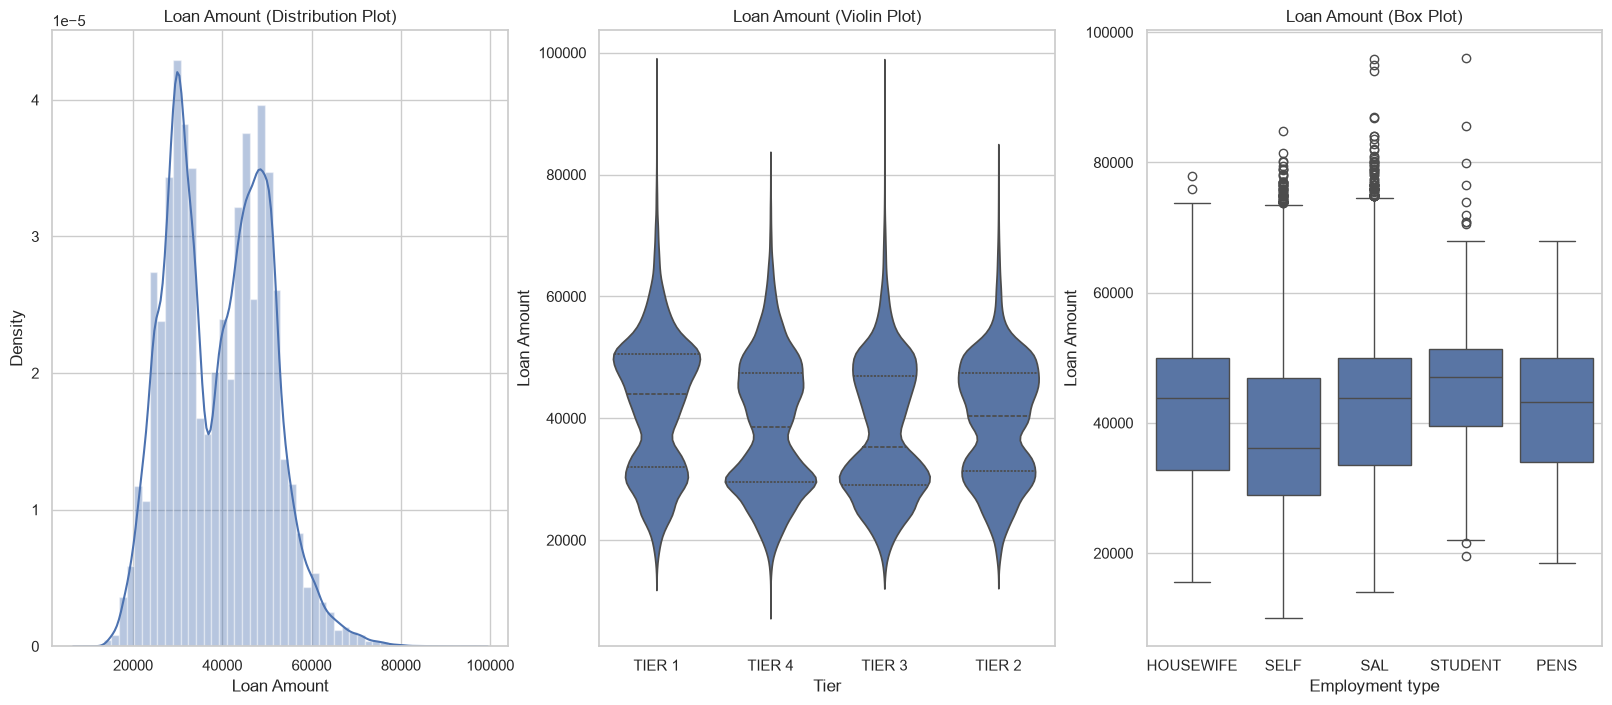

In [12]:
sns.set(style="whitegrid")

fig, ax=plt.subplots(nrows =1,ncols=3,figsize=(20,8))
ax[0].set_title("Loan Amount (Distribution Plot)")
sns.distplot(Loan_renamed['Loan Amount'],ax=ax[0])
ax[1].set_title("Loan Amount (Violin Plot)")
sns.violinplot(data =Loan_renamed, x='Tier',y='Loan Amount',ax=ax[1], inner="quartile")
ax[2].set_title("Loan Amount (Box Plot)")
sns.boxplot(data =Loan_renamed, x='Employment type',y='Loan Amount',ax=ax[2],orient='v')

1. Distribution Plot: They are 2 (bimodal) main sets of borrowers.Smaller and larger loan cust.

2. Violin Plot: The tier categories don't seem to strongly influence loan amount.

3. Box Plot: 

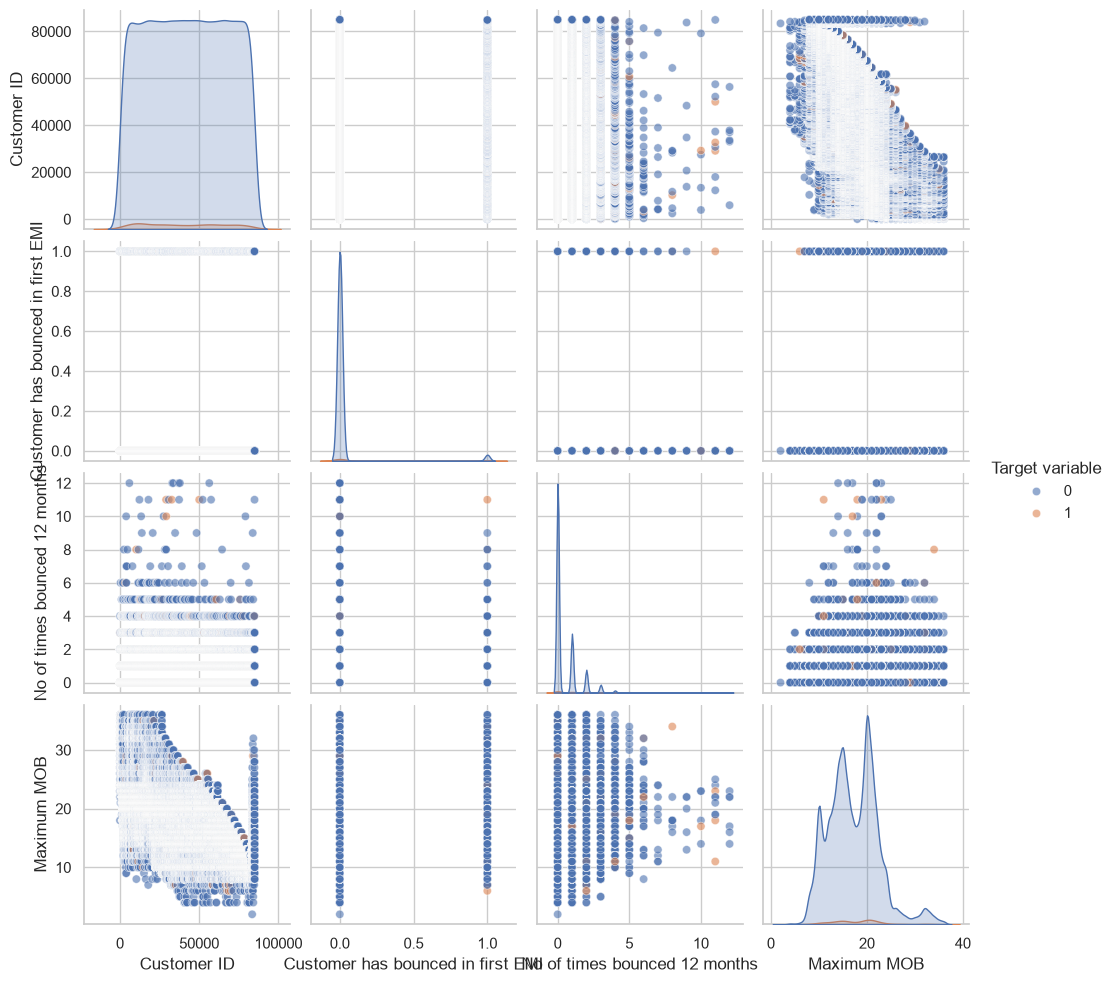

In [13]:
numeric_cols = Loan_renamed.select_dtypes(include=["number"]).columns.tolist()
selected_cols = numeric_cols[:4] + ["Target variable"]
sns.pairplot(Loan_renamed[selected_cols], hue='Target variable', diag_kind="kde", plot_kws={"alpha":0.6})
plt.show()

some of these are not linearly separable

In [14]:
# Create "Age (years)" from "Date of birth" if present
today = pd.Timestamp("2026-06-08")

if "Date of birth" in Loan_renamed.columns:

    # Parse Date of Birth
    dob_parsed = pd.to_datetime(
        Loan_renamed["Date of birth"],
        errors="coerce",
        dayfirst=False
    )

    # Calculate age in years
    age_years = np.floor(
        (today - dob_parsed).dt.days / 365.25
    )

    Loan_renamed["Age (years)"] = age_years

    # Drop original DOB
    Loan_renamed.drop(columns=["Date of birth"], inplace=True)

In [15]:
Loan_renamed.head()

,Customer ID,Customer has bounced in first EMI,No of times bounced 12 months,Maximum MOB,No of times bounced while repaying the loan,EMI,Loan Amount,Tenure,Dealer codes from where customer has purchased the Two wheeler,Product code of Two wheeler,...,No of secured loans,No of unsecured loans,No of new loans in last 3 months,Maximum amount sanctioned for any Two wheeler loan,No of times 30 days past due in last 6 months,No of times 60 days past due in last 6 months,No of times 90 days past due in last 3 months,Tier,Target variable,Age (years)
0,1,0,0,24.0,0.0,2432.0,46500.0,24.0,1385.0,SC,...,1,0,0,46500.0,0,0,0,TIER 1,0,52.0
1,2,0,1,24.0,1.0,1495.0,28168.0,24.0,2496.0,MO,...,1,0,0,28168.0,0,0,0,TIER 1,0,58.0
2,3,0,0,26.0,0.0,1707.0,38900.0,30.0,1346.0,SC,...,6,3,0,38900.0,31,31,16,TIER 1,0,43.0
3,4,0,0,24.0,0.0,2128.0,42900.0,24.0,1375.0,SC,...,1,0,0,42900.0,0,0,0,TIER 1,0,36.0
4,5,0,0,27.0,0.0,1824.0,40900.0,30.0,4140.0,MC,...,1,0,0,40900.0,0,0,0,TIER 1,0,41.0


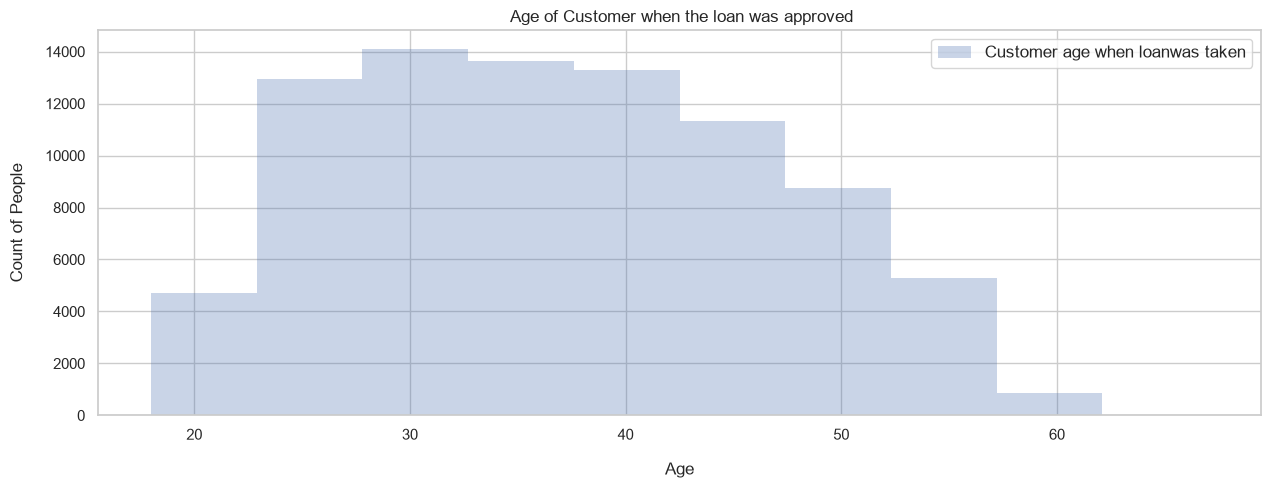

In [16]:
##Age- age at which the client took the loan
plt.figure(figsize=(15,5))

#bar plot
Loan_renamed['Customer age when loanwas taken'].plot(kind='hist',color='b',alpha=0.3, edgecolor='none')
plt.xlabel("Age", labelpad=14)
plt.ylabel("Count of People", labelpad=14)
plt.title(" Age of Customer when the loan was approved")
plt.legend(loc="best",prop={"size":12})

<Axes: xlabel='Customer age when loanwas taken', ylabel='Loan Amount'>

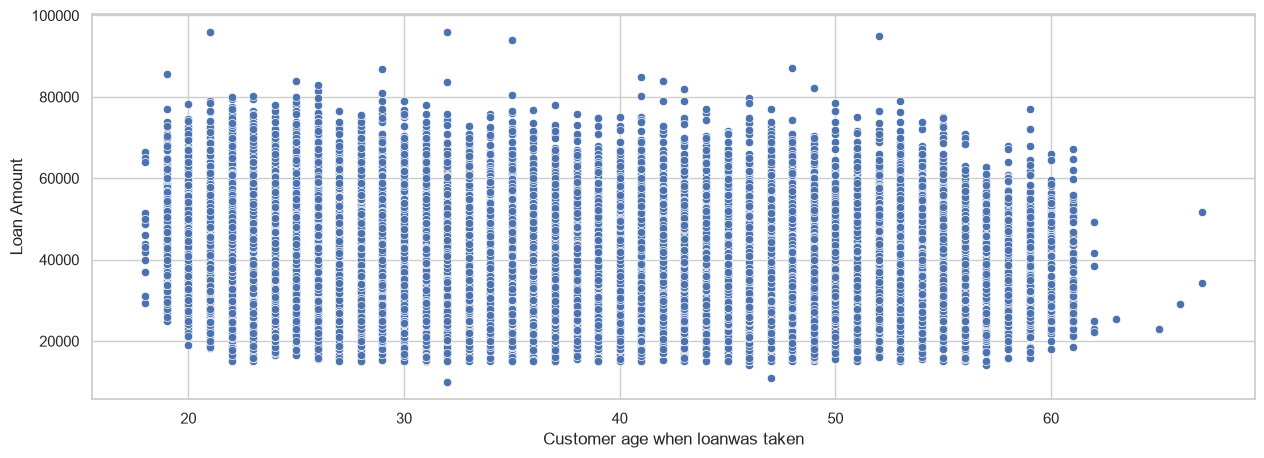

In [17]:
# Explore correlation between age and loan amount 
plt.figure(figsize=(15,5))
sns.scatterplot(x=Loan_renamed['Customer age when loanwas taken'],y='Loan Amount',data=Loan_renamed)

In [18]:
# gender = pd.get_dummies(Loan_renamed['Gender'])
# Loan_renamed=pd.concat([Loan_renamed,gender], axis=1)
# Loan_renamed = Loan_renamed.drop('Gender', axis=1)

In [19]:
Loan_renamed.info()

<class 'pandas.DataFrame'>
RangeIndex: 85048 entries, 0 to 85047
Data columns (total 27 columns):
 #   Column                                                          Non-Null Count  Dtype  
---  ------                                                          --------------  -----  
 0   Customer ID                                                     85048 non-null  int64  
 1   Customer has bounced in first EMI                               85048 non-null  int64  
 2   No of times bounced 12 months                                   85048 non-null  int64  
 3   Maximum MOB                                                     85048 non-null  float64
 4   No of times bounced while repaying the loan                     85048 non-null  float64
 5   EMI                                                             85048 non-null  float64
 6   Loan Amount                                                     85048 non-null  float64
 7   Tenure                                                      

In [20]:
dropped=['Dealer codes from where customer has purchased the Two wheeler']

Loan_renamed.drop(dropped,axis=1,inplace=True)

## 4. DATA CLEANING 

In [21]:
data=Loan_renamed.copy()

### 4.1 Imputing missing values 
To do, investigate them first and document the case for imputation, we might need to drop them.

In [22]:
CatVariables = data.select_dtypes(include=['object'])
NumVariables = data.select_dtypes(include=['float','int'])

#standardizing column names for easier usage
data.columns=data.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')
CatVariables=CatVariables.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')
NumVariables=NumVariables.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')

In [23]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 85048 entries, 0 to 85047
Data columns (total 26 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   customer_id                                         85048 non-null  int64  
 1   customer_has_bounced_in_first_emi                   85048 non-null  int64  
 2   no_of_times_bounced_12_months                       85048 non-null  int64  
 3   maximum_mob                                         85048 non-null  float64
 4   no_of_times_bounced_while_repaying_the_loan         85048 non-null  float64
 5   emi                                                 85048 non-null  float64
 6   loan_amount                                         85048 non-null  float64
 7   tenure                                              85048 non-null  float64
 8   product_code_of_two_wheeler                         85048 non-null  str    
 9   no_of_


 #### Strategies to deal with missing value
  Almost always real world data sets have missing values. This can be due, for example, users didn't fill some part of the forms or some transformations happened while collecting and cleaning the data before they send it to you. Sometimes missing values are informative and weren't generated randomly. Therefore, it's a good practice to add binary features to check if there is missing values in each row for each feature that has missing values. 
    
In our case, a number of the variables have missing values consistently pointing to a lapse in the data generation process. Thus we will consider deleting these observations only after exploring the performance of the model with imputed values. 
Columns with a significant portion of the observations missing will be dropped as the model we have opted for does not take in missing values. 
    
 Below are some of the most common strategies for dealing with missing values:\n",
- Simply delete all examples that have any missing values. This is usually done if the missing values are very small compared to the size of the data set and the missing values were random. In other words, the added binary features did not improve the model. One disadvantage for this strategy is that the model will throw an error when test data has missing values at prediction.

- Impute the missing values using the mean of each feature separately
- Impute the missing values using the median of each feature separately.
- Use *Multivariate Imputation by Chained Equations (MICE)*. The main disadvantage of MICE is that we can't use it as a transformer in sklearn pipelines and it requires to use the full data set when imputing the missing values. This means that there will be a risk of data leakage since we're using both training and test sets to impute the missing values. 

The following steps explain how MICE works:
- First step: Impute the missing values using the mean of each feature separately.
- Second step: For each feature that has missing values, we take all other features as predictors (including the ones that had missing values) and try to predict the values for this feature using linear regression for example. 
     The predicted values will replace the old values for that feature. We do this for all features that have missing values, i.e. each feature will be used once as a target variable to predict its values and the rest of the time as a predictor to predict other features' values. Therefore, one complete cycle (iteration) will be done once we run the model $k$ times to predict the $k$ features that have missing values. For our data set, each iteration will run the linear regression 6 times to predict the 6 features.
- Third step: Repeat step 2 until there is not much of change between predictions.
- Impute the missing values using K-Nearest Neighbors. We compute distance between all examples (excluding missing values) in the data set and take the average of k-nearest neighbors of each missing value. There's no implementation for it yet in sklearn and it's pretty inefficient to compute it since we'll have to go through all examples to calculate distances. Therefore, we'll skip this strategy in this notebook.

    
To evaluate each strategy, we'll use *Random Forest* classifier with hyperparameters' values guided by [Data-driven Advice for Applying Machine Learning to Bioinformatics Problems](https://arxiv.org/pdf/1708.05070.pdf) as a starting point.

Let's first create binary features for missing values and then prepare the data for each strategy discussed above. Next, we'll compute the 10-folds cross validation *AUC* score for all the models using training data."

In [24]:
#For quantitative data

numerical_cols = data[NumVariables]
categorical_cols = data[CatVariables]

imp_mean = SimpleImputer(missing_values=np.nan, strategy='median')
lat = imp_mean.fit_transform(numerical_cols)
imp_mode = SimpleImputer(missing_values=np.nan,strategy='most_frequent')
g_se = imp_mode.fit_transform(categorical_cols)

In [25]:
data[CatVariables]=g_se
data[NumVariables]=lat

In [26]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 85048 entries, 0 to 85047
Data columns (total 26 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   customer_id                                         85048 non-null  float64
 1   customer_has_bounced_in_first_emi                   85048 non-null  float64
 2   no_of_times_bounced_12_months                       85048 non-null  float64
 3   maximum_mob                                         85048 non-null  float64
 4   no_of_times_bounced_while_repaying_the_loan         85048 non-null  float64
 5   emi                                                 85048 non-null  float64
 6   loan_amount                                         85048 non-null  float64
 7   tenure                                              85048 non-null  float64
 8   product_code_of_two_wheeler                         85048 non-null  str    
 9   no_of_

### 4.2 Encoding

1. Label encoding 

We can  use  LabelEncoder to encode our variable to numbers. What a label encoder essentially does is that it sees the first value in the column and converts it to 0, next value to 1 and so on.The integer values have a natural ordered relationship between each other and machine learning algorithms may be able to understand and harness this relationship. This approach works reasonably well with tree models

2. One hot encoding 

For categorical variables where no such ordinal relationship exists, the integer/label encoding does not suffice.
In fact, using this encoding and allowing the model to assume a natural ordering between categories may result in poor performance or unexpected results (predictions halfway between categories).

In this case, a one-hot encoding can be applied to the integer representation. This is where the integer encoded variable is removed and a new binary variable is added for each unique integer value.

So if we have n levels in a category, we will get n-1 features.

In [27]:
# Dealing with categorical columns
# Label Encoding for object to numeric conversion
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for feature in CatVariables:
    data[feature] = le.fit_transform(data[feature].astype(str))


In [28]:
# Encoding
# Separating the numerical variables from the categorical variables
cat_var=data.select_dtypes(include=[object])
num_var = data.select_dtypes(include=['float','int'])

# Encoding
# Separating the numerical variables from the categorical variables
cat_var=data.select_dtypes(include=[object])
num_var = data.select_dtypes(include=['float','int'])

### 4.3 Class IMbalance 

Text(0.5, 1.0, 'Ratio of Customers Who Defaulted and Who did Not')

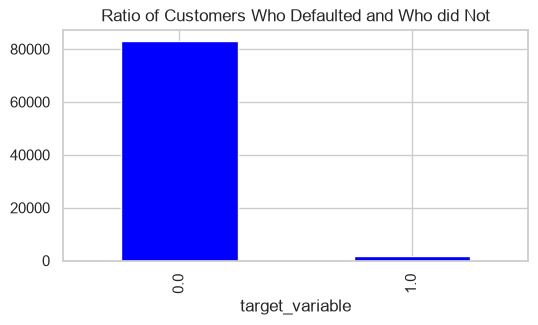

In [29]:
data['target_variable'].value_counts().plot(kind = "bar", figsize = (6,3),color='Blue')
plt.title("Ratio of Customers Who Defaulted and Who did Not")

Insight:  case of class imbalance in the target variable

In [30]:
X=data.drop(['customer_id','target_variable'],axis=1)
y=data[["target_variable"]]

In [31]:
X.head(10)

,customer_has_bounced_in_first_emi,no_of_times_bounced_12_months,maximum_mob,no_of_times_bounced_while_repaying_the_loan,emi,loan_amount,tenure,product_code_of_two_wheeler,no_of_advance_emi_paid,rate_of_interest,...,no_of_loans,no_of_secured_loans,no_of_unsecured_loans,no_of_new_loans_in_last_3_months,maximum_amount_sanctioned_for_any_two_wheeler_loan,no_of_times_30_days_past_due_in_last_6_months,no_of_times_60_days_past_due_in_last_6_months,no_of_times_90_days_past_due_in_last_3_months,tier,age_years
0,0.0,0.0,24.0,0.0,2432.0,46500.0,24.0,3,0.0,12.75,...,1.0,1.0,0.0,0.0,46500.0,0.0,0.0,0.0,0,52.0
1,0.0,1.0,24.0,1.0,1495.0,28168.0,24.0,1,0.0,13.65,...,1.0,1.0,0.0,0.0,28168.0,0.0,0.0,0.0,0,58.0
2,0.0,0.0,26.0,0.0,1707.0,38900.0,30.0,3,0.0,12.65,...,9.0,6.0,3.0,0.0,38900.0,31.0,31.0,16.0,0,43.0
3,0.0,0.0,24.0,0.0,2128.0,42900.0,24.0,3,2.0,9.50,...,1.0,1.0,0.0,0.0,42900.0,0.0,0.0,0.0,0,36.0
4,0.0,0.0,27.0,0.0,1824.0,40900.0,30.0,0,0.0,13.50,...,1.0,1.0,0.0,0.0,40900.0,0.0,0.0,0.0,0,41.0
5,0.0,2.0,28.0,3.0,1802.0,40800.0,30.0,3,0.0,13.00,...,1.0,1.0,0.0,0.0,40800.0,0.0,0.0,0.0,0,43.0
6,0.0,1.0,26.0,2.0,2047.0,45900.0,30.0,3,0.0,13.50,...,2.0,1.0,1.0,0.0,45900.0,1.0,0.0,0.0,0,61.0
7,0.0,0.0,24.0,0.0,2410.0,45900.0,24.0,3,0.0,13.00,...,1.0,1.0,0.0,0.0,45900.0,0.0,0.0,0.0,0,49.0
8,0.0,0.0,23.0,0.0,1255.0,23900.0,24.0,1,0.0,13.00,...,2.0,1.0,1.0,0.0,23900.0,0.0,0.0,0.0,0,37.0
9,0.0,1.0,18.0,2.0,1748.0,25000.0,18.0,1,0.0,17.20,...,1.0,1.0,0.0,0.0,25000.0,0.0,0.0,0.0,0,32.0


In [32]:
y.head(10)

,target_variable
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
5,0.0
6,0.0
7,0.0
8,0.0
9,0.0


In [33]:
y.value_counts()

target_variable
0.0                83194
1.0                 1854
Name: count, dtype: int64

In [34]:
y.nunique()

target_variable    2
dtype: int64

#### SMOTE
S𝒚𝒏𝒕𝒉𝒆𝒕𝒊𝒄 𝒎𝒊𝒏𝒐𝒓𝒊𝒕𝒚 𝒐𝒗𝒆𝒓𝒔𝒂𝒎𝒑𝒍𝒊𝒏𝒈 𝒕𝒆𝒄𝒉𝒏𝒊𝒒𝒖𝒆- creates examples of the minority class by looking at the distribution of the minority class and "guesses" what the other cases would have been 
- pick two points that are relatively closer to each other distance wise 
-  draw a line 
- generate a new point along that line 

It doesn't always work but a lot of time it works and it is a good technique to look at when there is no way of generating more data and the aforementioned techniques are not applicable per se 
It is better for increasing precision(𝙥𝙤𝙨𝙞𝙩𝙞𝙫𝙚 𝙞𝙙𝙚𝙣𝙩𝙞𝙛𝙞𝙚𝙙 𝙖𝙨 𝒕𝒉𝒂𝒕 𝒂𝒓𝒆 𝒑𝒐𝒔𝒊𝒕𝒊𝒗𝒆 ) but this comes at the cost of recall (𝒐𝒖𝒕 𝒐𝒇 𝒂𝒍𝒍 𝒕𝒉𝒆 𝒑𝒐𝒔𝒊𝒕𝒊𝒗𝒆𝒔 𝒘𝒉𝒊𝒄𝒉 𝒐𝒏𝒆𝒔 𝒉𝒂𝒗𝒆 𝒃𝒆𝒆𝒏 𝒄𝒐𝒓𝒓𝒆𝒄𝒕𝒍𝒚 𝒊𝒅𝒆𝒏𝒕𝒊𝒇𝒊𝒆𝒅)


array([[<Axes: title={'center': 'target_variable'}>]], dtype=object)

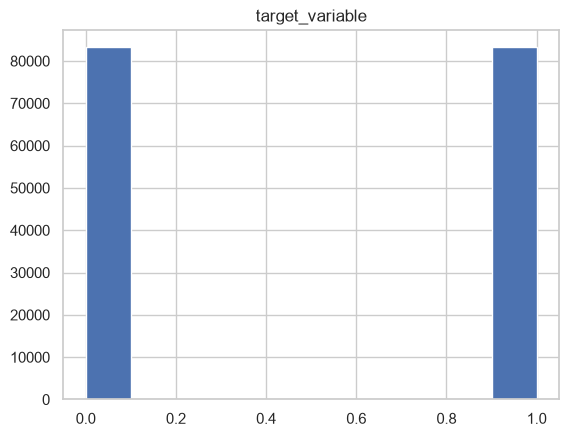

In [35]:
smote_sample=SMOTE(random_state=124,sampling_strategy='auto') # the sampling strategy can be one of float, str, dict or callable `float``,
#it corresponds to the desired ratio of the number of samples in the minority class over the number of samples in the majority class after resampling ie {1:500}
# ``'minority'``: resample only  minority class; 'not minority'``:all but the minority class; ``'not majority'``: all but the majority, ``'all'`` ,``'auto'``:
x_res, y_res=smote_sample.fit_resample(X,y)


# now plot the classes
y_res.hist()

With SMOTE we get a feature space with a similar distribution to the original data set, except that in this case we actually have a balanced ratio of the negative and positive examples. Thus our model should be able to learn the patterns associated with both defaults and non-defaults. Here we are interested in both an increase in precision and recall. 

In [36]:
print(x_res.shape,y_res.shape)

(166388, 24) (166388, 1)


In [37]:
print(y_res.value_counts())

target_variable
0.0                83194
1.0                83194
Name: count, dtype: int64


## Challenge: 
- Explore the linear separabillity of the two classes and document your intuition of the best model type to give you the best results. 
- Document the effect of multicolleaniarity in model performance. 
- Try different classification models and optimize your output for the best result
- Tune your model after learning these in Week 4 - The submission can be done without this step : It is worth noting that feature engineering is of much importance than hyperparametere tuning as the perfomance  improvement with the latter is always only marginal
- Generate Credit Scores based on the probability score from the model (Optional)
- Identify which customers fall into what category, based on the below ranking methodologies 
> #### The following forms our basis for rank ordering 
> - 0 - 200 Bad Customer ,
> - 201-350 2nd Worst, 
> - 351 - 500 Not So bad,
> - 501 - 700 Ideal guys, 
> - 700> Big loans 



## Exploring linear seperability

Linear Separability- To tell us how well the features in X can separate the target classes in y.

**Step 1: Train/test original data so that we can check for linear seperability on the actual data** 

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=124,
    stratify=y
)
#stratify=y makes sure the training and testing sets maintain approximately the same class proportions.

**Step 2: Apply smote on training data- to help the model during training**

In [39]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=124)

X_train_res, y_train_res = smote.fit_resample(
    X_train,
    y_train
)

In [40]:
print(X_train_res.shape)
print(y_train_res.value_counts())

(133110, 24)
target_variable
0.0                66555
1.0                66555
Name: count, dtype: int64


**Step 3: Feature Scaling: The features in this dataset are on very different scales**

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_res)

X_test_scaled = scaler.transform(X_test)

**Step 4: Use logistic regression as a linear classifier - it will create a decision boundary that will combine the features and get the probability of class 0 or 1**

In [42]:
from sklearn.linear_model import LogisticRegression

linear_model = LogisticRegression(
    max_iter=1000
)

linear_model.fit(X_train_scaled, y_train_res)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

**Step 5: Prediction**

In [43]:
y_pred = linear_model.predict(X_test_scaled)

**Step 6: Evaluation**

In [44]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.99      0.82      0.89     16639
         1.0       0.06      0.57      0.12       371

    accuracy                           0.81     17010
   macro avg       0.53      0.69      0.50     17010
weighted avg       0.97      0.81      0.88     17010



A precision of 0.06, recall of 0.57 and F1 score of 0.12 tells me that the linear boundary is not doing a good job of distinguishing between class 0 and 1

In [45]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[13586  3053]
 [  161   210]]


13,586 non-defaulters - correctly identified (TN)

3,053 non-defaulters - incorrectly classified as defaulters (FP)

161 defaulters - missed by the model (FN)

210 defaulters - correctly identified (TP)

Therefore,

The distinction between defaulters and non-defaulters is not easily captured by a simple linear boundary.

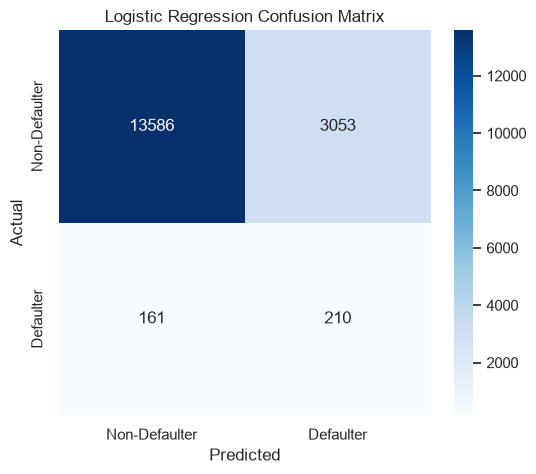

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Defaulter", "Defaulter"],
    yticklabels=["Non-Defaulter", "Defaulter"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

**Regularization**

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

log_model = LogisticRegression(max_iter=1000)

param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100]
}

log_grid = GridSearchCV(
    estimator=log_model,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

log_grid.fit(X_train_scaled, y_train_res)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with higher

In [60]:
print("Best parameters:", log_grid.best_params_)
print("Best CV F1:", log_grid.best_score_)

Best parameters: {'C': 100}
Best CV F1: 0.7954163548542789


In [61]:
best_log_model = log_grid.best_estimator_

y_pred_log_tuned = best_log_model.predict(X_test_scaled)

In [62]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_log_tuned))

print(confusion_matrix(y_test, y_pred_log_tuned))

              precision    recall  f1-score   support

         0.0       0.99      0.82      0.89     16639
         1.0       0.06      0.57      0.12       371

    accuracy                           0.81     17010
   macro avg       0.53      0.69      0.51     17010
weighted avg       0.97      0.81      0.88     17010

[[13589  3050]
 [  161   210]]


Even after regularization the model still can't properly distinguish between the two classes

**Step 7 Visualization using Principal Component Analysis**

Because the data set has 24 features,it is not possible to visualize them and how they have been grouped into classes using a normal graph.

Therefore, after research I found a method known as PCA; a technique used to reduce the number of variables while keeping as much of the important information in the data as possible.

In [47]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_train_scaled)

In [48]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Target"] = y_train_res.values

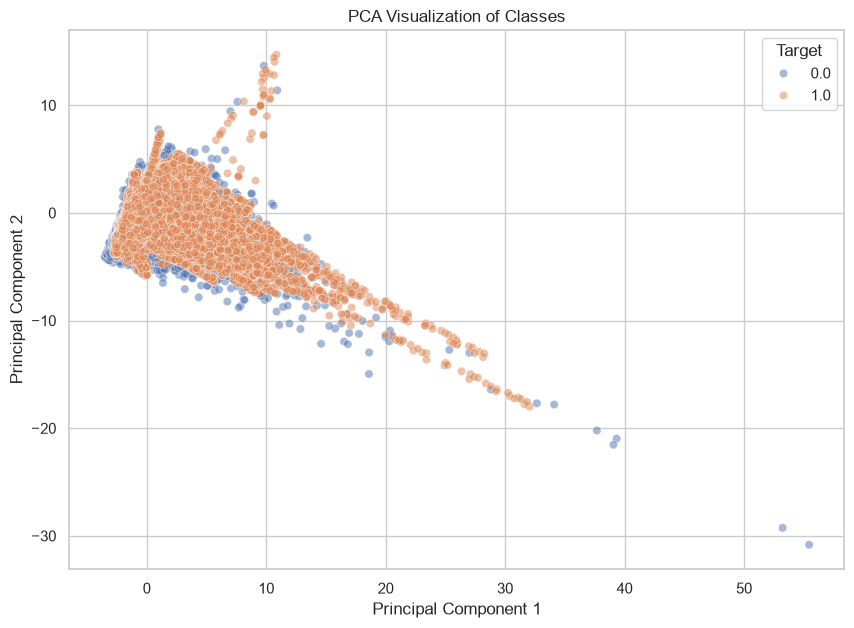

In [49]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Target",
    alpha=0.5
)

plt.title("PCA Visualization of Classes")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

That means the two classes have substantial overlap in the PCA representation.

Therefore this confirms what the linear regression evaluation suggested that the defaulters and non-defaulters do not appear to be cleanly separated into distinct groups.

**Step 8: Non linear models**

Decision Tree

In [50]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=124,
    class_weight=None
)

dt_model.fit(X_train_res, y_train_res)

y_pred_dt = dt_model.predict(X_test)

In [51]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_dt))

print(confusion_matrix(y_test, y_pred_dt))

              precision    recall  f1-score   support

         0.0       0.98      0.97      0.98     16639
         1.0       0.10      0.15      0.12       371

    accuracy                           0.95     17010
   macro avg       0.54      0.56      0.55     17010
weighted avg       0.96      0.95      0.96     17010

[[16137   502]
 [  315    56]]


Random Forest

In [52]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=124,
    n_jobs=-1
)

rf_model.fit(X_train_res, y_train_res)

y_pred_rf = rf_model.predict(X_test)

In [53]:
print(classification_report(y_test, y_pred_rf))

print(confusion_matrix(y_test, y_pred_rf))

              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99     16639
         1.0       0.31      0.08      0.12       371

    accuracy                           0.98     17010
   macro avg       0.64      0.54      0.56     17010
weighted avg       0.97      0.98      0.97     17010

[[16574    65]
 [  342    29]]


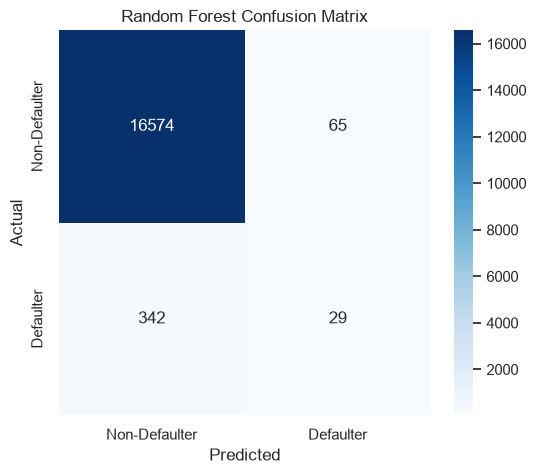

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Defaulter", "Defaulter"],
    yticklabels=["Non-Defaulter", "Defaulter"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [55]:
from sklearn.metrics import f1_score, precision_score, recall_score

print("Logistic Regression")
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

print("\nRandom Forest")
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))

Logistic Regression
Precision: 0.06435795280416795
Recall: 0.5660377358490566
F1: 0.11557512383048982

Random Forest
Precision: 0.30851063829787234
Recall: 0.07816711590296496
F1: 0.12473118279569892


**Hyperparameter tuning**

RandomForest showed the best performance, therefore I chose to proceed with tuning it

In [56]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(
    random_state=124,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", "log2"]
}

rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=8,
    scoring="f1",
    cv=3,
    random_state=124,
    n_jobs=-1,
    verbose=2
)

rf_random.fit(X_train_res, y_train_res)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...dom_state=124)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",8
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",124
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichretur

In [57]:
print(rf_random.best_params_)

print("Best CV F1:", rf_random.best_score_)

{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 30}
Best CV F1: 0.9856378195627299


In [58]:
best_rf = rf_random.best_estimator_

y_pred_rf_tuned = best_rf.predict(X_test)

print(classification_report(y_test, y_pred_rf_tuned))

              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99     16639
         1.0       0.31      0.09      0.14       371

    accuracy                           0.98     17010
   macro avg       0.64      0.54      0.56     17010
weighted avg       0.97      0.98      0.97     17010



In [64]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Logistic Regression + Regularization",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_log_tuned),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf_tuned)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_log_tuned),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf_tuned)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_log_tuned),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf_tuned)
    ]
})

comparison

,Model,Precision,Recall,F1 Score
0,Logistic Regression,0.064358,0.566038,0.115575
1,Logistic Regression + Regularization,0.064417,0.566038,0.115671
2,Decision Tree,0.100358,0.150943,0.120560
3,Random Forest,0.308511,0.078167,0.124731
4,Tuned Random Forest,0.305556,0.088949,0.137787


**Generate credit scores based on the probability score from the model.**

In [65]:
# probability of class one
y_probability = rf_random.best_estimator_.predict_proba(X_test)[:, 1]

In [68]:
credit_score = 850 * (1 - y_probability)

In [69]:
results = X_test.copy()

results["Probability_of_Default"] = y_probability
results["Credit_Score"] = credit_score

In [72]:
def rank_customer(score):
    if score <= 200:
        return "Bad Customer"
    elif score <= 350:
        return "2nd Worst"
    elif score <= 500:
        return "Not So Bad"
    elif score <= 700:
        return "Ideal Guys"
    else:
        return "Big Loans"

results["Customer_Category"] = results["Credit_Score"].apply(rank_customer)

In [73]:
results[[
    "Probability_of_Default",
    "Credit_Score",
    "Customer_Category"
]].head(20)

,Probability_of_Default,Credit_Score,Customer_Category
62331,0.048936,808.404133,Big Loans
84871,0.005000,845.750000,Big Loans
32408,0.000287,849.756157,Big Loans
62079,0.030179,824.348214,Big Loans
53132,0.040681,815.421368,Big Loans
15952,0.001105,849.060539,Big Loans
78331,0.017054,835.503804,Big Loans
35696,0.002250,848.087500,Big Loans
28842,0.004167,846.458333,Big Loans
16430,0.000008,849.992809,Big Loans
